# 04 — Evaluate & Compare Models

Evaluates all ten trained models on the held-out test set: Accuracy, Precision, Recall, F1, ROC-AUC, confusion matrices, and an overlaid ROC curve plot. Requires `03_train_models.ipynb` to have been run first.

In [13]:
import pickle

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
)

from config import DATA_DIR, FIGURES_DIR

MODELS_DIR = DATA_DIR / "models"

MODEL_KEYS = [
    ("decision_tree", "orig", "Decision Tree (original)"),
    ("decision_tree", "smote", "Decision Tree (SMOTE)"),
    ("naive_bayes", "orig", "Naive Bayes (original)"),
    ("naive_bayes", "smote", "Naive Bayes (SMOTE)"),
    ("knn", "orig", "k-NN (original)"),
    ("knn", "smote", "k-NN (SMOTE)"),
    ("random_forest", "orig", "Random Forest (original)"),
    ("random_forest", "smote", "Random Forest (SMOTE)"),
    ("adaboost", "orig", "AdaBoost (original)"),
    ("adaboost", "smote", "AdaBoost (SMOTE)"),
    # Tuned variants (from 03b_hyperparameter_tuning.ipynb)
    ("decision_tree", "orig_tuned", "Decision Tree (original, tuned)"),
    ("decision_tree", "smote_tuned", "Decision Tree (SMOTE, tuned)"),
    ("naive_bayes", "orig_tuned", "Naive Bayes (original, tuned)"),
    ("naive_bayes", "smote_tuned", "Naive Bayes (SMOTE, tuned)"),
    ("knn", "orig_tuned", "k-NN (original, tuned)"),
    ("knn", "smote_tuned", "k-NN (SMOTE, tuned)"),
    ("random_forest", "orig_tuned", "Random Forest (original, tuned)"),
    ("random_forest", "smote_tuned", "Random Forest (SMOTE, tuned)"),
    ("adaboost", "orig_tuned", "AdaBoost (original, tuned)"),
    ("adaboost", "smote_tuned", "AdaBoost (SMOTE, tuned)"),
    # Gradient boosting candidates (untuned + tuned)
    ("xgboost", "orig_tuned", "XGBoost (original, tuned)"),
    ("xgboost", "smote_tuned", "XGBoost (SMOTE, tuned)"),
    ("lightgbm", "orig_tuned", "LightGBM (original, tuned)"),
    ("lightgbm", "smote_tuned", "LightGBM (SMOTE, tuned)"),
]

## Load test set

In [14]:
X_test = pd.read_csv(DATA_DIR / "X_test.csv")
y_test = pd.read_csv(DATA_DIR / "y_test.csv").iloc[:, 0]

print(f"Test shape: {X_test.shape}")

Test shape: (8000, 25)


## Helper functions

In [15]:
def load_model(name, suffix):
    path = MODELS_DIR / f"{name}_{suffix}.pkl"
    with open(path, "rb") as f:
        return pickle.load(f)


def evaluate_model(model, X_test, y_test, label):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": label,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_proba),
    }

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    return metrics, cm, (fpr, tpr)


def plot_confusion_matrix(cm, label):
    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Diabetes", "Diabetes"],
                yticklabels=["No Diabetes", "Diabetes"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix: {label}")
    fig.tight_layout()
    safe_name = label.lower().replace(" ", "_").replace("(", "").replace(")", "")
    fig.savefig(FIGURES_DIR / f"confusion_matrix_{safe_name}.png", dpi=150)
    plt.show()


def plot_roc_curves(roc_data):
    fig, ax = plt.subplots(figsize=(7, 6))
    for label, (fpr, tpr) in roc_data.items():
        ax.plot(fpr, tpr, label=label)
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves — Model Comparison")
    ax.legend(loc="lower right", fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "roc_curves_comparison.png", dpi=150)
    plt.show()

## Evaluate all ten models

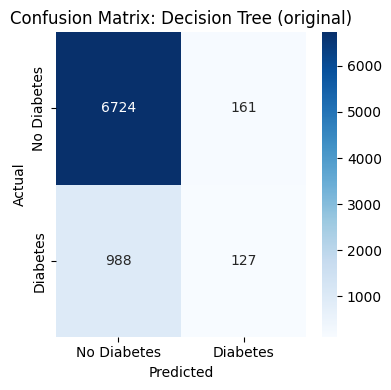

Evaluated: Decision Tree (original)


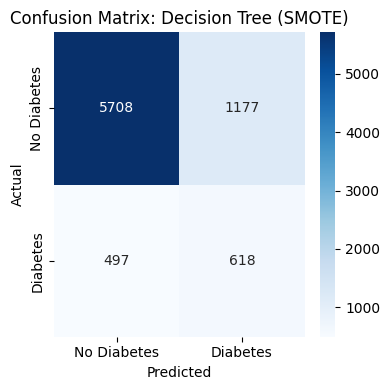

Evaluated: Decision Tree (SMOTE)


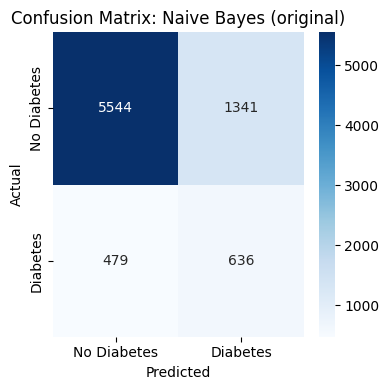

Evaluated: Naive Bayes (original)


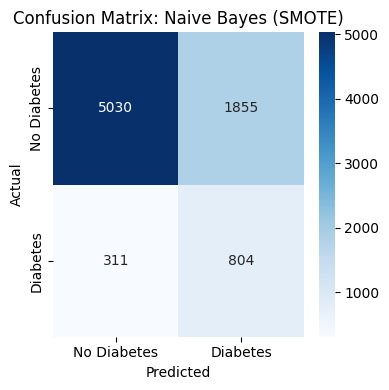

Evaluated: Naive Bayes (SMOTE)


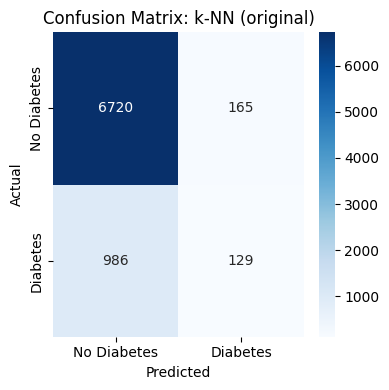

Evaluated: k-NN (original)


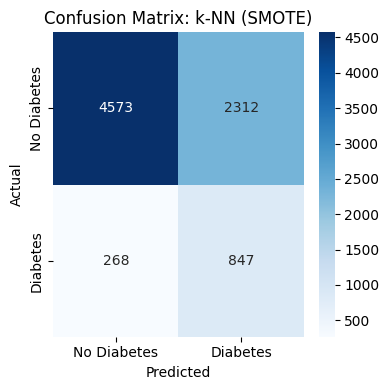

Evaluated: k-NN (SMOTE)


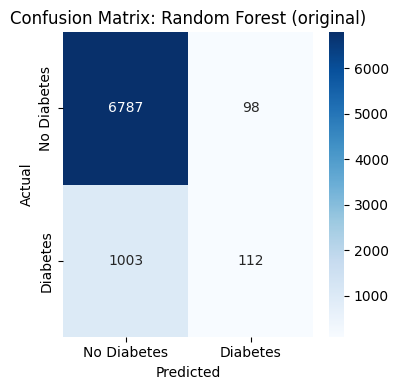

Evaluated: Random Forest (original)


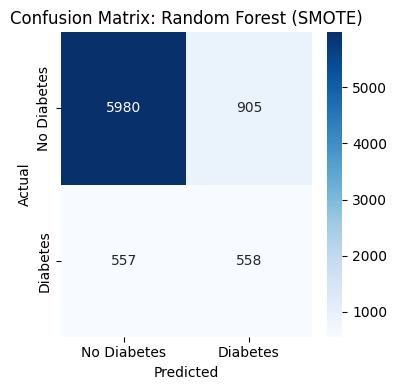

Evaluated: Random Forest (SMOTE)


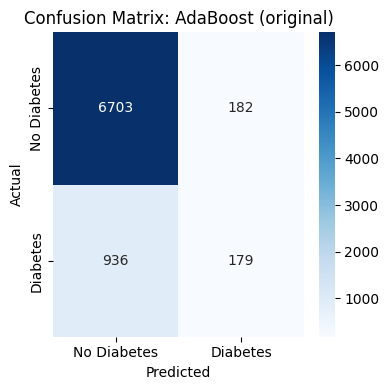

Evaluated: AdaBoost (original)


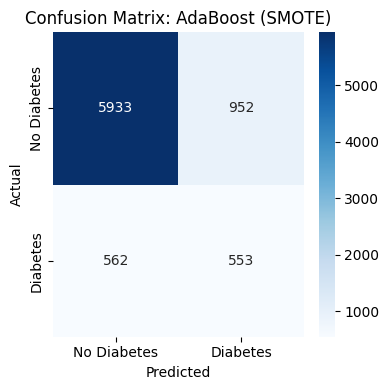

Evaluated: AdaBoost (SMOTE)


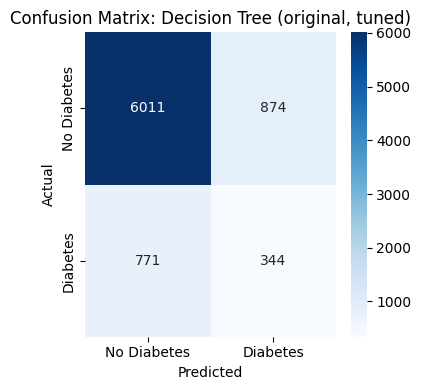

Evaluated: Decision Tree (original, tuned)


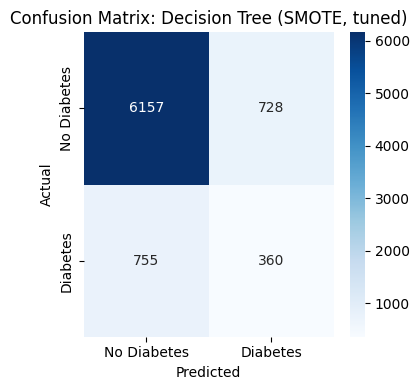

Evaluated: Decision Tree (SMOTE, tuned)


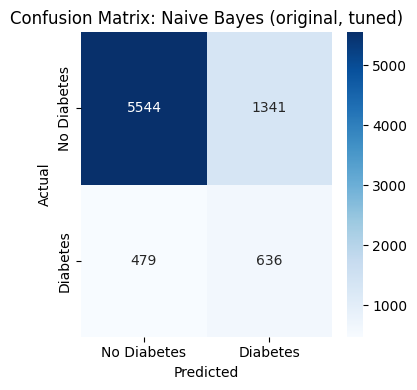

Evaluated: Naive Bayes (original, tuned)


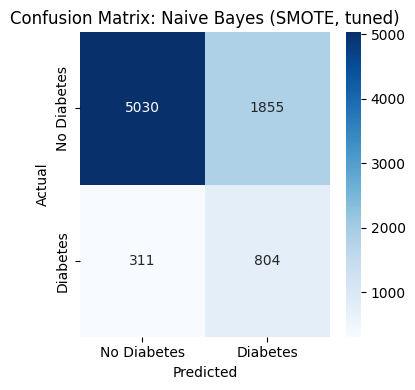

Evaluated: Naive Bayes (SMOTE, tuned)


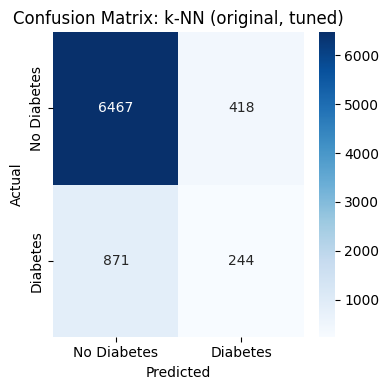

Evaluated: k-NN (original, tuned)


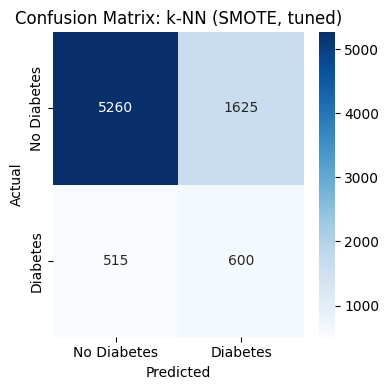

Evaluated: k-NN (SMOTE, tuned)


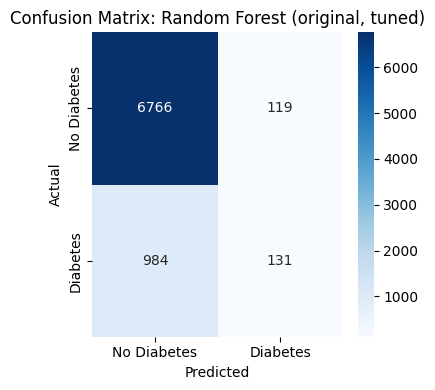

Evaluated: Random Forest (original, tuned)


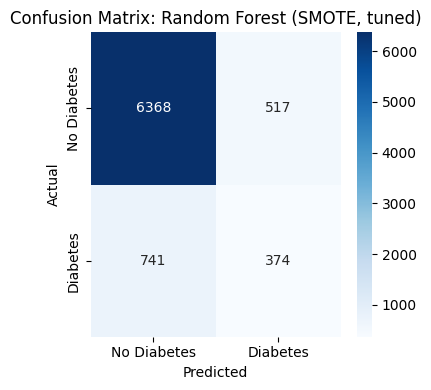

Evaluated: Random Forest (SMOTE, tuned)


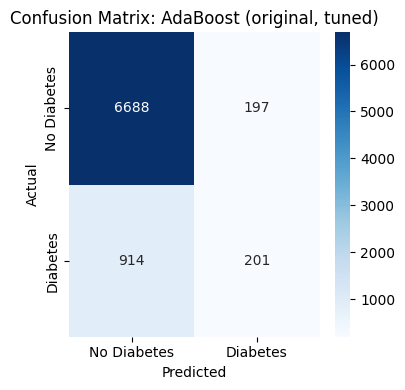

Evaluated: AdaBoost (original, tuned)


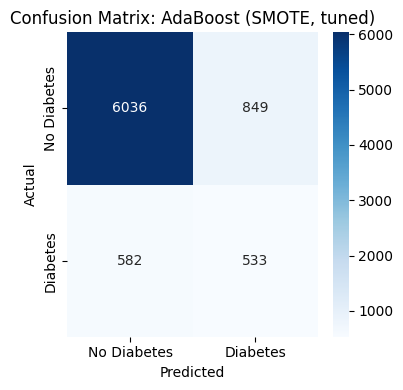

Evaluated: AdaBoost (SMOTE, tuned)


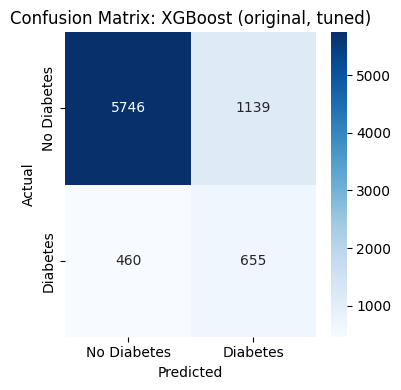

Evaluated: XGBoost (original, tuned)


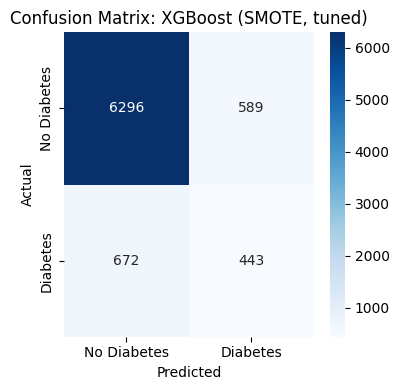

Evaluated: XGBoost (SMOTE, tuned)


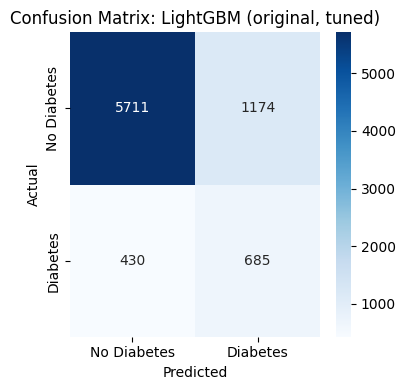

Evaluated: LightGBM (original, tuned)


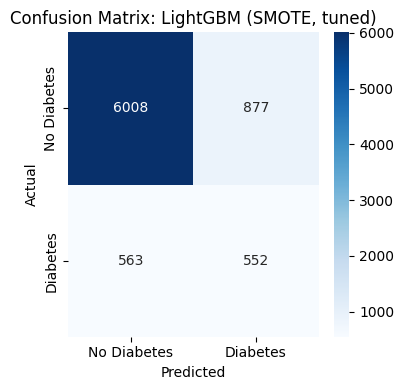

Evaluated: LightGBM (SMOTE, tuned)


In [16]:
results = []
roc_data = {}

for name, suffix, label in MODEL_KEYS:
    model = load_model(name, suffix)
    metrics, cm, roc = evaluate_model(model, X_test, y_test, label)
    results.append(metrics)
    roc_data[label] = roc
    plot_confusion_matrix(cm, label)
    print(f"Evaluated: {label}")

## Comparison table

In [17]:
results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
results_df.to_csv(DATA_DIR / "model_comparison_results.csv", index=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
22,"LightGBM (original, tuned)",0.799500,0.368478,0.614350,0.460659,0.820640
20,"XGBoost (original, tuned)",0.800125,0.365106,0.587444,0.450327,0.816516
23,"LightGBM (SMOTE, tuned)",0.820000,0.386284,0.495067,0.433962,0.813453
7,Random Forest (SMOTE),0.817250,0.381408,0.500448,0.432894,0.811103
19,"AdaBoost (SMOTE, tuned)",0.821125,0.385673,0.478027,0.426912,0.807626
3,Naive Bayes (SMOTE),0.729250,0.302369,0.721076,0.426073,0.787452
13,"Naive Bayes (SMOTE, tuned)",0.729250,0.302369,0.721076,0.426073,0.787452
1,Decision Tree (SMOTE),0.790750,0.344290,0.554260,0.424742,0.791238
9,AdaBoost (SMOTE),0.810750,0.367442,0.495964,0.422137,0.804467
21,"XGBoost (SMOTE, tuned)",0.842375,0.429264,0.397309,0.412669,0.816310


## ROC curve comparison

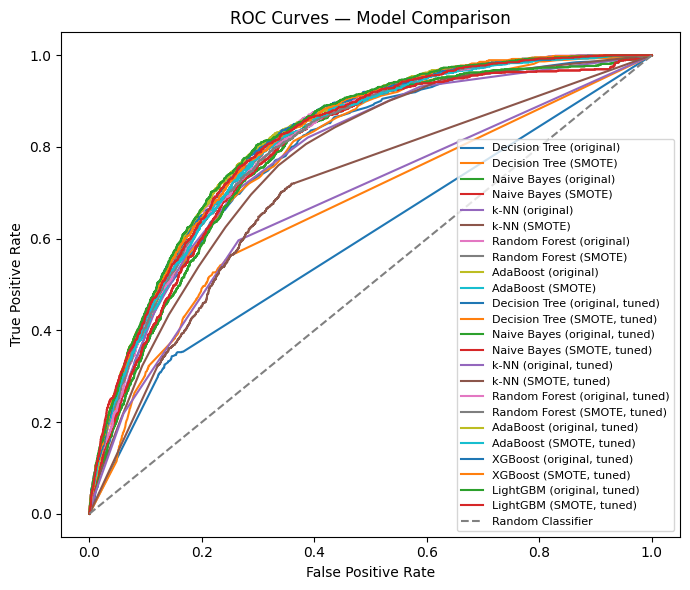

Saved results table to C:\Users\ardao\Desktop\Projects\Bil476\data\model_comparison_results.csv
Saved figures to C:\Users\ardao\Desktop\Projects\Bil476\figures


In [18]:
plot_roc_curves(roc_data)

print(f"Saved results table to {DATA_DIR / 'model_comparison_results.csv'}")
print(f"Saved figures to {FIGURES_DIR}")